# Milestone 4 — Self-Supervised Pre-Training

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds
from gridfm import train as tr
from gridfm.model import GridFMv01, count_parameters

PROC_DIR = ROOT / "data" / "processed"
CKPT_DIR = ROOT / "checkpoints"
FIG_DIR = ROOT / "results" / "figures" / "m4"
STATS_DIR = ROOT / "results" / "m4_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PRETRAIN_GRIDS = ["case24", "case30", "case118"]
EPOCHS, SEED = 300, 42
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)

train_loader, val_loader = tr.make_loaders(PROC_DIR, PRETRAIN_GRIDS, batch_size=64, seed=SEED)
model = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
print("device: %s | params: %.0fk | train graphs: %d | val graphs: %d"
      % (device, count_parameters(model) / 1e3,
         len(train_loader.dataset), len(val_loader.dataset)))

config = {"grids": PRETRAIN_GRIDS, "epochs": EPOCHS, "batch_size": 64, "lr": 3e-4,
          "clip": 1.0, "sched": "ReduceLROnPlateau(0.7, 10)", "w1": 0.01, "w2": 0.99,
          "model": {"per_head": 32, "heads": 4, "num_layers": 4, "dropout": 0.1},
          "seed": SEED}
with open(STATS_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

device: cpu | params: 284k | train graphs: 4374 | val graphs: 547


## The run

In [2]:
history = tr.fit(model, train_loader, val_loader, epochs=EPOCHS, ckpt_dir=CKPT_DIR,
                 device=device, lr=config["lr"], clip=config["clip"],
                 resume=True, log_every=10, tag="pretrain")
history.to_csv(STATS_DIR / "history.csv", index=False)
best = history.loc[history.val_total.idxmin()]
print("\nbest validation loss %.4f at epoch %d | total wall time %.1f min"
      % (best.val_total, int(best.epoch), history.time_s.sum() / 60))

epoch   0 | train 820.1355 (mse 1.0478 pbe 828.4091) | val 54.6376 | lr 3.0e-04 | 12s


epoch  10 | train 2.4475 (mse 0.0181 pbe 2.4721) | val 6.0144 | lr 3.0e-04 | 11s


epoch  20 | train 0.8058 (mse 0.0095 pbe 0.8138) | val 1.3572 | lr 3.0e-04 | 11s


epoch  30 | train 0.4004 (mse 0.0075 pbe 0.4043) | val 0.5578 | lr 3.0e-04 | 11s


epoch  40 | train 0.2648 (mse 0.0066 pbe 0.2674) | val 0.3706 | lr 3.0e-04 | 11s


...

epoch 260 | train 0.0448 (mse 0.0026 pbe 0.0452) | val 0.0920 | lr 2.9e-06 | 11s


epoch 270 | train 0.0452 (mse 0.0026 pbe 0.0456) | val 0.0926 | lr 2.9e-06 | 11s


epoch 280 | train 0.0446 (mse 0.0026 pbe 0.0450) | val 0.0909 | lr 2.0e-06 | 11s


epoch 290 | train 0.0456 (mse 0.0026 pbe 0.0460) | val 0.0917 | lr 1.4e-06 | 11s


epoch 299 | train 0.0446 (mse 0.0026 pbe 0.0451) | val 0.0907 | lr 1.0e-06 | 11s

best validation loss 0.0871 at epoch 183 | total wall time 56.1 min


## Training curves

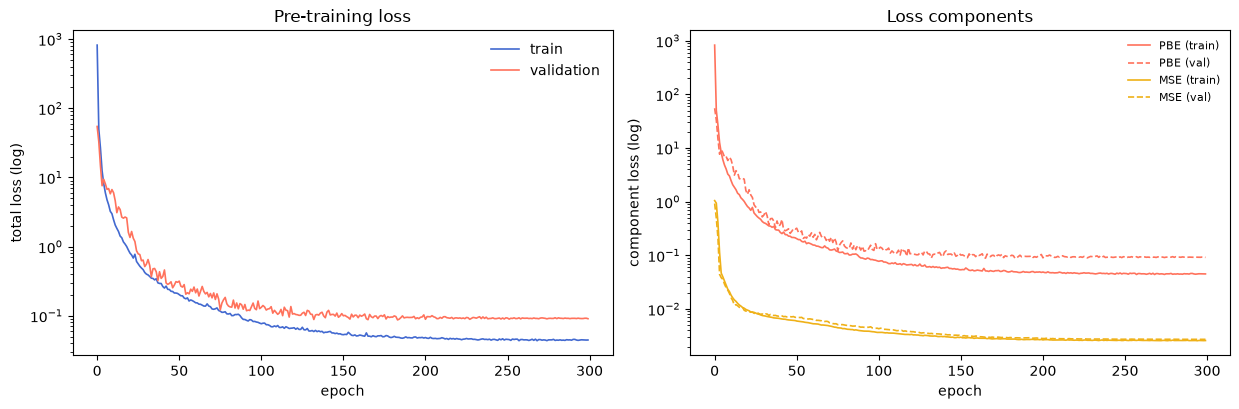

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(history.epoch, history.train_total, color="#4269D0", lw=1.2, label="train")
axes[0].plot(history.epoch, history.val_total, color="#FF725C", lw=1.2, label="validation")
axes[0].set_yscale("log")
axes[0].set(xlabel="epoch", ylabel="total loss (log)", title="Pre-training loss")
axes[0].legend(frameon=False)

axes[1].plot(history.epoch, history.train_pbe, color="#FF725C", lw=1.2, label="PBE (train)")
axes[1].plot(history.epoch, history.val_pbe, color="#FF725C", lw=1.2, ls="--", label="PBE (val)")
axes[1].plot(history.epoch, history.train_mse, color="#EFB118", lw=1.2, label="MSE (train)")
axes[1].plot(history.epoch, history.val_mse, color="#EFB118", lw=1.2, ls="--", label="MSE (val)")
axes[1].set_yscale("log")
axes[1].set(xlabel="epoch", ylabel="component loss (log)", title="Loss components")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_training_curves.png", bbox_inches="tight")
plt.show()

## The learning-rate schedule at work

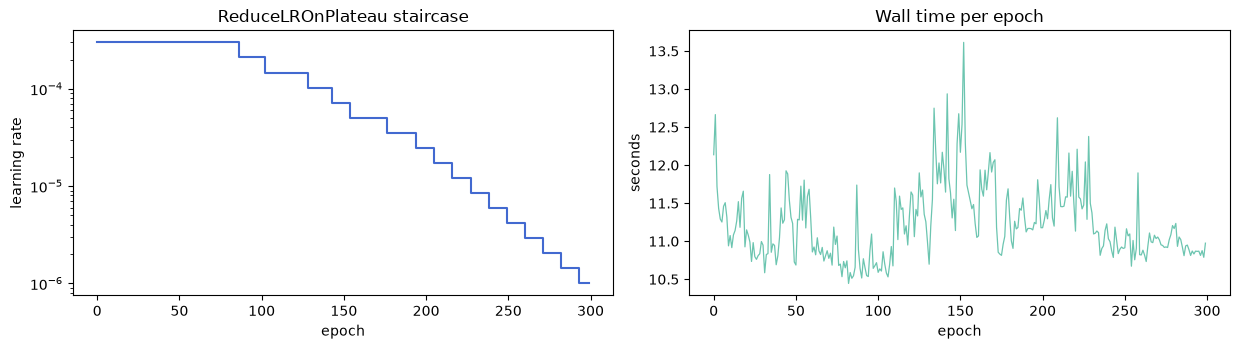

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
axes[0].step(history.epoch, history.lr, where="post", color="#4269D0")
axes[0].set_yscale("log")
axes[0].set(xlabel="epoch", ylabel="learning rate", title="ReduceLROnPlateau staircase")
axes[1].plot(history.epoch, history.time_s, color="#6CC5B0", lw=0.9)
axes[1].set(xlabel="epoch", ylabel="seconds", title="Wall time per epoch")
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_lr_and_time.png", bbox_inches="tight")
plt.show()

## Before / after: the Milestone-3 teaser scenario, revisited

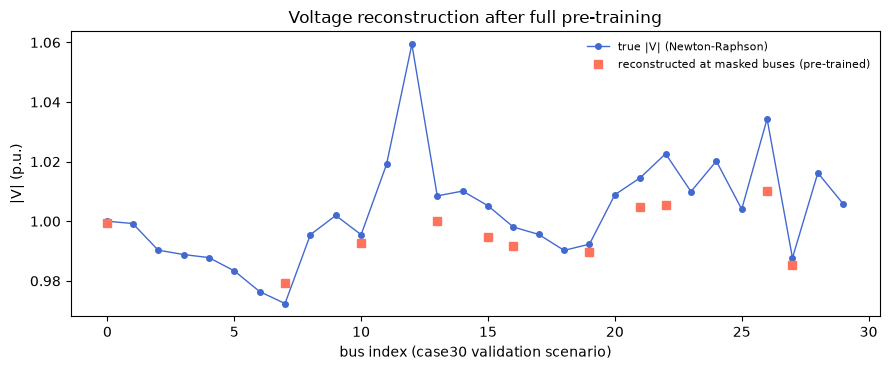

masked |V| error: mean 0.0083 p.u. (M3 sanity run: ~0.25) | worst 0.0242 p.u.


In [5]:
best_state = torch.load(CKPT_DIR / "final_pretrain_best.pt", weights_only=False)
model.load_state_dict(best_state["model"])
model.eval().to("cpu")

val30 = ds.load_processed(PROC_DIR, "case30", "val")
g = val30[0]
xm, m = ds.random_mask(g.x, generator=torch.Generator().manual_seed(7))
with torch.no_grad():
    pred = model(xm, g.edge_index, g.edge_attr)

vm_true = g.x[:, 4].numpy()
idx = np.where(m[:, 4].numpy())[0]
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(vm_true, "o-", color="#4269D0", lw=1, ms=4, label="true |V| (Newton-Raphson)")
ax.plot(idx, pred[idx, 4].numpy(), "s", color="#FF725C", ms=6,
        label="reconstructed at masked buses (pre-trained)")
ax.set(xlabel="bus index (case30 validation scenario)", ylabel="|V| (p.u.)",
       title="Voltage reconstruction after full pre-training")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_before_after.png", bbox_inches="tight")
plt.show()
err = np.abs(pred[idx, 4].numpy() - vm_true[idx])
print("masked |V| error: mean %.4f p.u. (M3 sanity run: ~0.25) | worst %.4f p.u."
      % (err.mean(), err.max()))